**Orders**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from pathlib import Path

In [2]:
file_path = Path.cwd().parent.parent/"Excel"/"5_Orders.xlsx"
df = pd.read_excel(file_path)
df

,Order_ID,Order_Date,Product_ID,Warehouse_ID,Customer_ID,Quantity,Discount,Order_Status,Revenue
0,ORD1000000,2025-12-01,P1951,W115,C16553,4.0,0.0,Returned,1525.48
1,ORD1000001,2025-01-05,P1277,W113,C12342,4.0,10.0,Delivered,857.05
2,ORD1000002,2025-06-06,P1761,W108,C18945,6.0,15.0,Delivered,2500.79
3,ORD1000003,2025-04-29,P1137,W100,C12526,7.0,0.0,Delivered,2697.45
4,ORD1000004,2025-03-24,P1613,W101,C12314,5.0,15.0,Returned,2871.17
...,...,...,...,...,...,...,...,...,...
500995,ORD1114378,2025-12-23,P1834,W100,C18105,4.0,15.0,Delivered,1188.67
500996,ORD1073788,2025-05-17,P1799,W117,C12546,1.0,0.0,Cancelled,80.40
500997,ORD1313441,2025-04-19,P1608,W102,C16593,1.0,20.0,Delivered,119.04
500998,ORD1498071,2025-08-19,P1226,W117,C13942,1.0,0.0,Returned,752.73


In [3]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501000 entries, 0 to 500999
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Order_ID      497828 non-null  object        
 1   Order_Date    498497 non-null  datetime64[ns]
 2   Product_ID    497846 non-null  object        
 3   Warehouse_ID  497904 non-null  object        
 4   Customer_ID   497822 non-null  object        
 5   Quantity      498497 non-null  float64       
 6   Discount      498494 non-null  float64       
 7   Order_Status  497853 non-null  object        
 8   Revenue       498496 non-null  float64       
dtypes: datetime64[ns](1), float64(3), object(5)
memory usage: 34.4+ MB


In [4]:
# Upper, Trimming and Consistent null values
columns = ["Order_ID", "Product_ID", "Warehouse_ID", "Customer_ID", "Order_Status"]
for col in columns:
    df[col] = df[col].str.upper()
    df[col] = df[col].str.strip()
nulls = ["N/A", "NA", "NULL", "UNKNOWN", ""]
df.replace(nulls, np.nan, inplace=True)
df["Order_Status"] = df["Order_Status"].str.capitalize()
df["Order_Status"] = df["Order_Status"].str.strip()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501000 entries, 0 to 500999
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Order_ID      495289 non-null  object        
 1   Order_Date    498497 non-null  datetime64[ns]
 2   Product_ID    495265 non-null  object        
 3   Warehouse_ID  495420 non-null  object        
 4   Customer_ID   495302 non-null  object        
 5   Quantity      498497 non-null  float64       
 6   Discount      498494 non-null  float64       
 7   Order_Status  495381 non-null  object        
 8   Revenue       498496 non-null  float64       
dtypes: datetime64[ns](1), float64(3), object(5)
memory usage: 34.4+ MB


In [5]:
# Dropping duplicates except nulls
df["Order_ID"].isna().sum()
mask = df["Order_ID"].notna()
df = pd.concat([
    df[mask].drop_duplicates(subset=["Order_ID"], keep="first"),
    df[~mask]
]).sort_index()
df.reset_index(drop=True, inplace=True)

In [6]:
# Replacing null values in Order ID
for i in range(len(df)):
    value = df.loc[i, "Order_ID"]
    if not pd.notna(value):
        df.loc[i, "Order_ID"] = f"ORD{1000000+i}"
df["Order_ID"].isna().sum()
df["Order_ID"].duplicated().sum()

np.int64(0)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500013 entries, 0 to 500012
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Order_ID      500013 non-null  object        
 1   Order_Date    497513 non-null  datetime64[ns]
 2   Product_ID    494286 non-null  object        
 3   Warehouse_ID  494440 non-null  object        
 4   Customer_ID   494325 non-null  object        
 5   Quantity      497513 non-null  float64       
 6   Discount      497513 non-null  float64       
 7   Order_Status  494402 non-null  object        
 8   Revenue       497514 non-null  float64       
dtypes: datetime64[ns](1), float64(3), object(5)
memory usage: 34.3+ MB


In [8]:
inventory_path = Path.cwd().parent.parent/"Data"/"Cleaned"/"Inventory.csv"
inventory_df = pd.read_csv(inventory_path)
inventory_df

,Inventory_ID,Product_ID,Warehouse_ID,Date,Opening_Stock,Received_Qty,Sold_Qty,Damaged_Qty,Closing_Stock
0,INV100000,P1051,W109,2025-07-01,2185.0,325.0,672.0,3.0,1835.0
1,INV100001,P1976,W102,2025-08-12,1544.0,593.0,281.0,0.0,1856.0
2,INV100002,P1328,W107,2025-06-17,613.0,542.0,248.0,1.0,906.0
3,INV100003,P1097,W105,2025-01-04,521.0,522.0,372.0,2.0,669.0
4,INV100004,P1160,W110,2025-11-06,1146.0,256.0,340.0,0.0,1062.0
...,...,...,...,...,...,...,...,...,...
365005,INV465005,P1831,W116,2025-11-15,937.0,73.0,213.0,0.0,797.0
365006,INV465006,P1023,W116,2025-05-30,292.0,342.0,469.0,1.0,164.0
365007,INV465007,P1367,W117,2025-05-08,2278.0,262.0,448.0,0.0,2092.0
365008,INV465008,P1995,W104,2025-01-12,1294.0,418.0,37.0,1.0,1674.0


In [9]:
# Mapping Warehouse ID and Product ID
df.loc[df["Product_ID"]=="P999999", "Product_ID"] = np.nan
mapping = (
    inventory_df.dropna(subset=["Product_ID"])
      .drop_duplicates(subset=["Warehouse_ID"])
      .set_index("Warehouse_ID")["Product_ID"]
      .to_dict()
)
df["Product_ID"] = df["Product_ID"].fillna(df["Warehouse_ID"].map(mapping))
df["Product_ID"].isna().sum()

np.int64(0)

In [10]:
# Mapping Product ID and Warehouse ID
mapping = (
    inventory_df.dropna(subset=["Warehouse_ID"])
    .drop_duplicates(subset=["Product_ID"])
    .set_index("Product_ID")["Warehouse_ID"]
    .to_dict()
)
df["Warehouse_ID"] = df["Warehouse_ID"].fillna(df["Product_ID"].map(mapping))
df["Warehouse_ID"].isna().sum()

np.int64(0)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500013 entries, 0 to 500012
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Order_ID      500013 non-null  object        
 1   Order_Date    497513 non-null  datetime64[ns]
 2   Product_ID    500013 non-null  object        
 3   Warehouse_ID  500013 non-null  object        
 4   Customer_ID   494325 non-null  object        
 5   Quantity      497513 non-null  float64       
 6   Discount      497513 non-null  float64       
 7   Order_Status  494402 non-null  object        
 8   Revenue       497514 non-null  float64       
dtypes: datetime64[ns](1), float64(3), object(5)
memory usage: 34.3+ MB


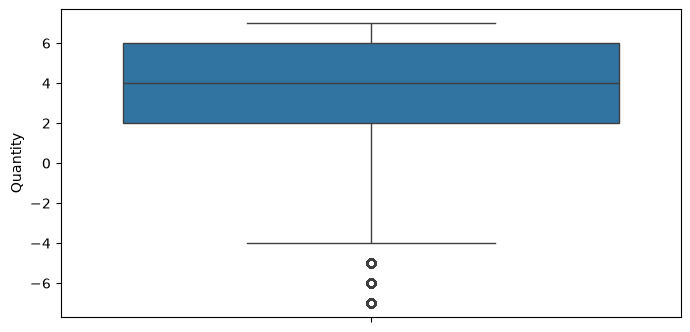

count    497513.000000
mean          4.000002
std           1.999386
min           1.000000
25%           2.000000
50%           4.000000
75%           6.000000
max           7.000000
Name: Quantity, dtype: float64

In [12]:
# Checking and correcting negative values in Quantity
plt.figure(figsize=(8,4))
sb.boxplot(df["Quantity"])
plt.show()
df.loc[df["Quantity"]<0, "Quantity"] *= -1
df["Quantity"].describe()

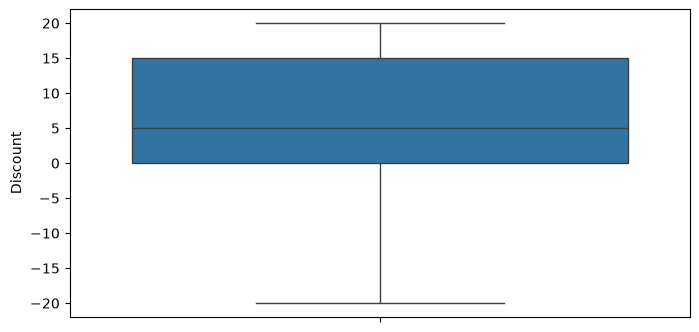

count    497513.000000
mean          8.339893
std           7.451948
min           0.000000
25%           0.000000
50%          10.000000
75%          15.000000
max          20.000000
Name: Discount, dtype: float64

In [13]:
# Checking and correcting negative values in Discount
plt.figure(figsize=(8,4))
sb.boxplot(df["Discount"])
plt.show()
df.loc[df["Discount"]<0, "Discount"] *= -1
df["Discount"].describe()

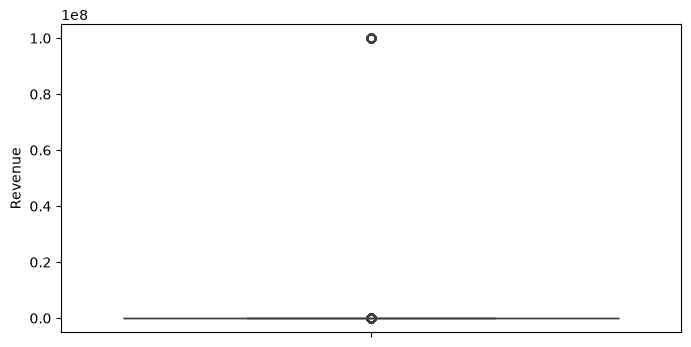

count    497414.000000
mean       1492.063695
std        1617.152898
min          18.410000
25%         491.490000
50%         988.880000
75%        1899.412500
max       23136.120000
Name: Revenue, dtype: float64

In [14]:
# Checking and correcting negative values in Revenue
plt.figure(figsize=(8,4))
sb.boxplot(df["Revenue"])
plt.show()
df["Revenue"].describe()
df.loc[df["Revenue"]<0, "Revenue"] *= -1
df.loc[df["Revenue"]==99999999, "Revenue"] = np.nan
df["Revenue"].describe()

In [15]:
products_path = Path.cwd().parent.parent/"Data"/"Cleaned"/"Products.csv"
products_df = pd.read_csv(products_path)
products_df

,Product_ID,Product_Name,Category,Sub_Category,Unit_Cost,Selling_Price,Supplier_ID
0,P1000,Product 1,Office,Stationery,344.99,701.83,S131
1,P1001,Product 2,Beauty,Makeup,266.87,460.73,S108
2,P1002,Product 3,Toys,Plush,194.66,268.68,S139
3,P1003,Product 4,Fashion,Footwear,149.63,177.36,S119
4,P1004,Product 5,Office,Office supplies,210.06,288.91,S189
...,...,...,...,...,...,...,...
995,P1995,Product 996,Fmcg,Personal care,106.67,197.06,S110
996,P1996,Product 997,Fmcg,Personal care,130.52,177.40,S125
997,P1997,Product 998,Toys,Action toys,111.23,133.17,S141
998,P1998,Product 999,Home & kitchen,Appliances,188.99,242.41,S126


In [16]:
df = df.merge(
    products_df[["Product_ID", "Unit_Cost"]],
    on="Product_ID",
    how="left"
)

In [17]:
df["Quantity"] = df["Quantity"].fillna(
    df["Revenue"]/(df["Unit_Cost"] * (1 - df["Discount"]/100))
).round(0)

In [18]:
calculated_discount = (
    ((df["Quantity"] * df["Unit_Cost"]) - df["Revenue"])
    / (df["Unit_Cost"] * df["Quantity"])
) * 100

calculated_discount = calculated_discount.abs().round(2)

median_discount = calculated_discount[calculated_discount <= 100].median()

df["Discount"] = df["Discount"].fillna(
    calculated_discount.where(calculated_discount <= 100, median_discount)
)

In [19]:
df["Revenue"] = df["Revenue"].fillna(
    df["Unit_Cost"] * df["Quantity"] * (1 - df["Discount"]/100)
).round(2)
df.drop("Unit_Cost", axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500013 entries, 0 to 500012
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Order_ID      500013 non-null  object        
 1   Order_Date    497513 non-null  datetime64[ns]
 2   Product_ID    500013 non-null  object        
 3   Warehouse_ID  500013 non-null  object        
 4   Customer_ID   494325 non-null  object        
 5   Quantity      499987 non-null  float64       
 6   Discount      500013 non-null  float64       
 7   Order_Status  494402 non-null  object        
 8   Revenue       499996 non-null  float64       
dtypes: datetime64[ns](1), float64(3), object(5)
memory usage: 34.3+ MB


In [20]:
df.to_csv("../../Data/Cleaned/Orders.csv", index=False)